Milestone 2:- Visual Exploration and Delay Trends

STEP 1: Setup Environment

1️⃣ Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

STEP 2: Load Cleaned Dataset

In [2]:
df = pd.read_csv("C:/Users/chand/OneDrive/Desktop/AirFly Insights/data/processed/cleaned_airline_data.csv")


In [3]:
df.head()

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,SecurityDelay,CarrierDelay,ArrivalDelay,DepartureDelay,Year,Month,DepartureHour,Route,IsDelayed,IsCancelled
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,...,32,23,45,38,2022,6,23,Coldfoot Airport - CXF,0,0
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,110,12,30,27,2022,12,6,Kugluktuk Airport - YCO,0,0
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,...,110,45,60,55,2022,1,4,Grenoble-Isère Airport - GNB,0,0
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,...,33,8,18,12,2022,9,13,Ottawa / Gatineau Airport - YND,1,0
4,VBu4gW,Lisle,Floyd,Male,25,China,Copán Ruinas Airport,HN,Honduras,NAM,...,41,67,80,75,2022,7,15,Copán Ruinas Airport - RUY,0,0


In [3]:
# Handle Missing Values
df=df.dropna(subset=['ArrivalDelay'])

In [9]:
df.fillna(0, inplace=True)   # 0 means no delay, using this helps retain all records by replacing missing values with 0, avoiding data loss during analysis.
                             #This assumes missing delays mean no delay, which simplifies processing but may slightly affect accuracy.

In [5]:
df.shape

(1837, 29)

Check basic info:

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Passenger ID          1837 non-null   object
 1   First Name            1837 non-null   object
 2   Last Name             1837 non-null   object
 3   Gender                1837 non-null   object
 4   Age                   1837 non-null   int64 
 5   Nationality           1837 non-null   object
 6   Airport Name          1837 non-null   object
 7   Airport Country Code  1837 non-null   object
 8   Country Name          1837 non-null   object
 9   Airport Continent     1837 non-null   object
 10  Continents            1837 non-null   object
 11  Departure Date        1837 non-null   object
 12  Arrival Airport       1837 non-null   object
 13  Pilot Name            1837 non-null   object
 14  Flight Status         1837 non-null   object
 15  Day of Departure      1837 non-null   

In [7]:
df.describe()

,Age,WeatherDelay,NASDelay,SecurityDelay,CarrierDelay,ArrivalDelay,DepartureDelay,Year,Month,DepartureHour,IsDelayed,IsCancelled
count,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.000000,1837.0,1837.000000,1837.000000,1837.000000,1837.000000
mean,46.206315,45.205770,86.181818,53.781165,39.535656,57.072945,52.906369,2022.0,6.589004,11.103430,0.321720,0.337507
std,26.025909,30.237011,38.458458,26.460148,25.060242,29.286562,28.754254,0.0,3.404526,6.932304,0.467263,0.472988
min,1.000000,1.000000,11.000000,6.000000,2.000000,5.000000,3.000000,2022.0,1.000000,0.000000,0.000000,0.000000
25%,23.000000,18.000000,55.000000,32.000000,18.000000,34.000000,30.000000,2022.0,4.000000,5.000000,0.000000,0.000000
50%,47.000000,41.000000,90.000000,54.000000,35.000000,55.000000,50.000000,2022.0,7.000000,11.000000,0.000000,0.000000
75%,69.000000,71.000000,119.000000,76.000000,60.000000,81.000000,77.000000,2022.0,9.000000,17.000000,1.000000,1.000000
max,90.000000,102.000000,146.000000,110.000000,95.000000,120.000000,115.000000,2022.0,12.000000,23.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
Day of Departure        0
Time of Departure       0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
CarrierDelay            0
ArrivalDelay            0
DepartureDelay          0
Year                    0
Month                   0
DepartureHour           0
Route                   0
IsDelayed               0
IsCancelled             0
dtype: int64

STEP 3: Feature Engineering 

For time-based analysis:

In [9]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'])

df['Month'] = df['Departure Date'].dt.month
df['DayOfWeek'] = df['Departure Date'].dt.day_name()
df['DepartureHour'] = pd.to_datetime(df['Time of Departure']).dt.hour

In [12]:
df[['WeatherDelay','NASDelay','SecurityDelay','ArrivalDelay','DepartureDelay']].head()

,WeatherDelay,NASDelay,SecurityDelay,ArrivalDelay,DepartureDelay
0,102,145,32,45,38
1,1,51,110,30,27
2,2,92,110,60,55
3,3,14,33,18,12
4,87,132,41,80,75


WEEK 3 – VISUAL EXPLORATION

univariate and bivariate visual analysis

In [13]:
df.columns.tolist()

['Passenger ID',
 'First Name',
 'Last Name',
 'Gender',
 'Age',
 'Nationality',
 'Airport Name',
 'Airport Country Code',
 'Country Name',
 'Airport Continent',
 'Continents',
 'Departure Date',
 'Arrival Airport',
 'Pilot Name',
 'Flight Status',
 'Day of Departure',
 'Time of Departure',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'CarrierDelay',
 'ArrivalDelay',
 'DepartureDelay',
 'Year',
 'Month',
 'DepartureHour',
 'Route',
 'IsDelayed',
 'IsCancelled',
 'DayOfWeek']

STEP 4: 1. UNIVARIATE ANALYSIS

In [14]:
df['Gender'].value_counts()

Gender
Male      934
Female    903
Name: count, dtype: int64

In [15]:
df['Flight Status'].value_counts()

Flight Status
On Time      626
Cancelled    620
Delayed      591
Name: count, dtype: int64

In [16]:
df['Airport Continent'].value_counts()

Airport Continent
NAM    616
AS     331
OC     277
EU     236
AF     198
SAM    179
Name: count, dtype: int64

In [17]:

df['IsDelayed'].value_counts()

IsDelayed
0    1246
1     591
Name: count, dtype: int64

1. Top Airlines (Bar Chart)

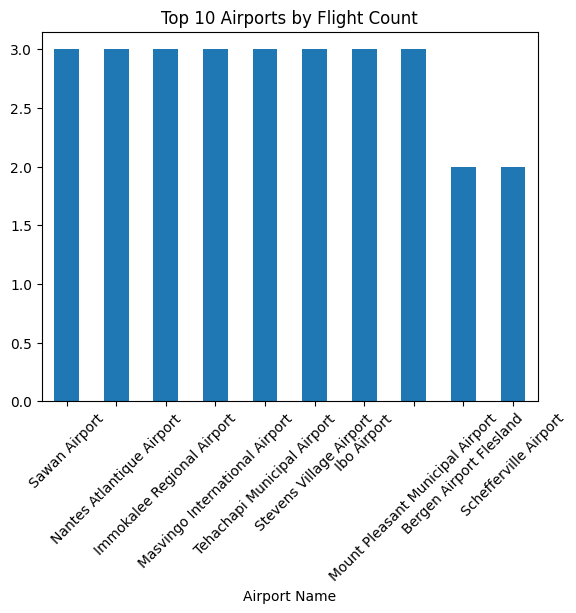

In [18]:
top_airports = df['Airport Name'].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top 10 Airports by Flight Count")
plt.xticks(rotation=45)
plt.show()

2. Busiest Months

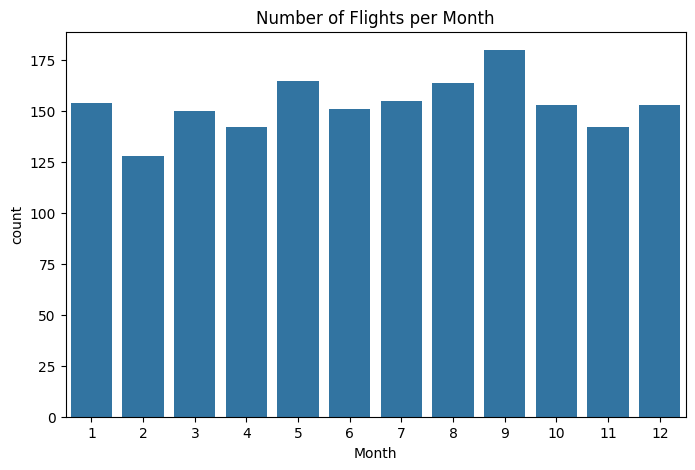

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Month', data=df)
plt.title("Number of Flights per Month")
plt.show()

Insight:

Helps identify busy travel months.Shows seasonal traffic.

3. Flights by Day of Week

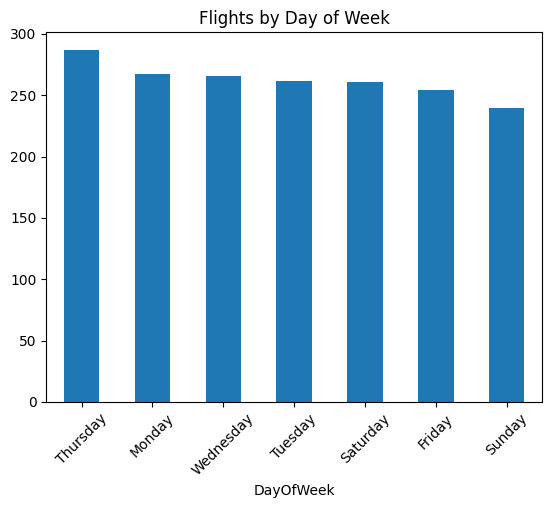

In [20]:
plt.figure()
df['DayOfWeek'].value_counts().plot(kind='bar')
plt.title("Flights by Day of Week")
plt.xticks(rotation=45)
plt.show()

4. Age Distribution (Histogram)

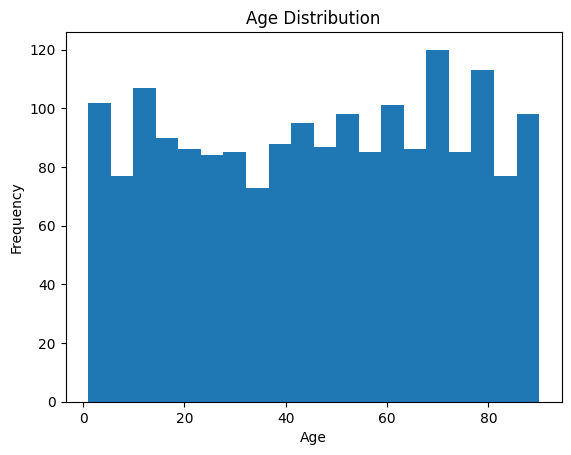

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

5. Gender Distribution (Bar Chart)

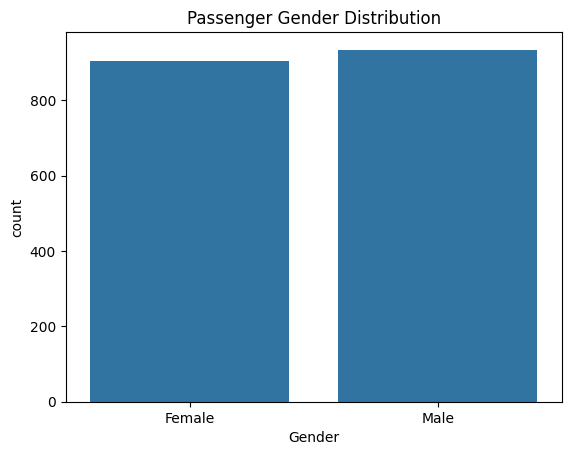

In [22]:
# Gender Distribution
sns.countplot(x='Gender', data=df)
plt.title("Passenger Gender Distribution")
plt.show()

The graph displays the number of male and female passengers traveling.

If the bars are similar, it indicates balanced participation of both genders in air travel.

Any noticeable difference may indicate travel trends or demographic patterns among passengers.

6. Flight Status Distribution

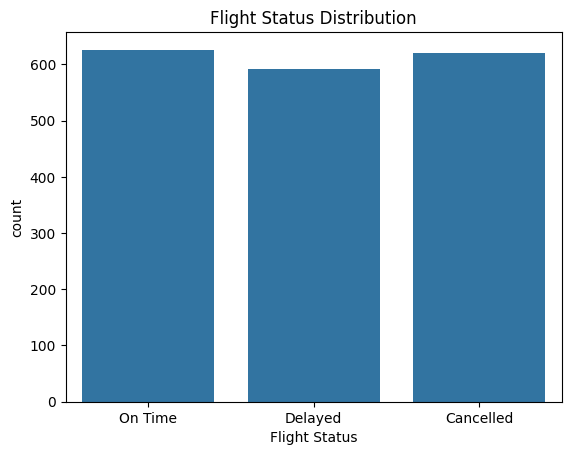

In [14]:
# Flight Status Distribution
sns.countplot(x='Flight Status', data=df)
plt.title("Flight Status Distribution")
plt.show()

The chart shows the distribution of flight statuses such as On-Time, Delayed, and Cancelled.

Most flights appear to be on time, indicating efficient scheduling and operations.

A smaller proportion of flights are delayed or cancelled, suggesting operational or external factors affecting some flights.

7. Airport Continent Distribution

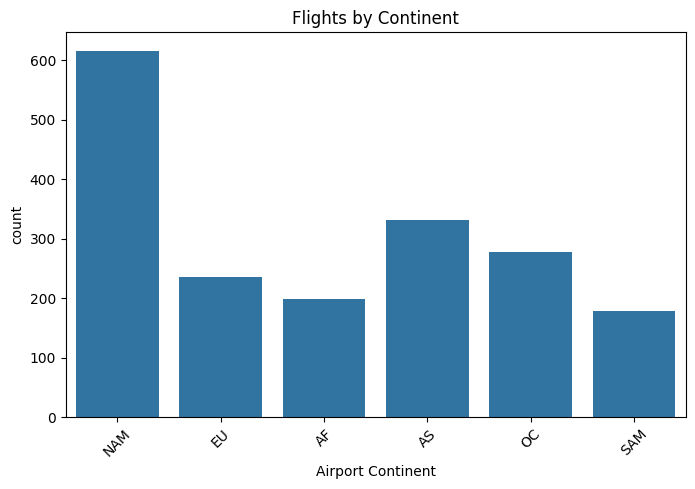

In [10]:
# Airport Continent Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Airport Continent', data=df)
plt.title("Flights by Continent")
plt.xticks(rotation=45)
plt.show()

Insight:

This chart represents the number of flights operating across different continents.

Continents with higher counts indicate major aviation hubs or higher travel demand.

Lower counts may reflect limited connectivity or fewer routes.

It shows which regions have more flights.

Important for route analysis.

8. Flight Distribution by Hour

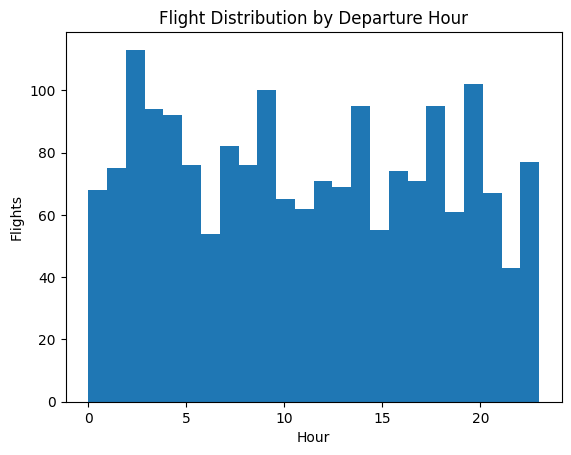

In [25]:
plt.figure()
plt.hist(df['DepartureHour'], bins=24)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Flights")
plt.show()

 STEP 5: 2. BIVARIATE VISUALIZATIONS

1. Gender vs Flight Status

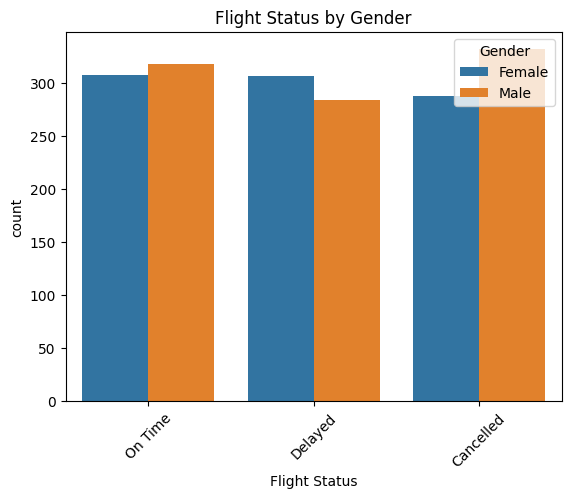

In [26]:
# Flight Status vs Gender
sns.countplot(x='Flight Status', hue='Gender', data=df)
plt.title("Flight Status by Gender")
plt.xticks(rotation=45)
plt.show()

This visualization compares flight status across passenger genders.

It helps determine whether delays or cancellations affect one gender more than the other.

In most cases, the distribution should be similar, indicating no gender-based operational bias.

2. Continent vs Flight Status

<Figure size 640x480 with 0 Axes>

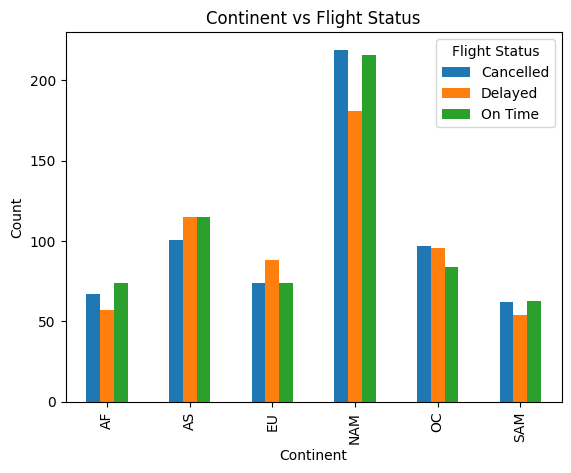

In [27]:
plt.figure()
pd.crosstab(df['Airport Continent'], df['Flight Status']).plot(kind='bar')
plt.title("Continent vs Flight Status")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.show()

3. DayOfWeek vs IsDelayed

<Figure size 640x480 with 0 Axes>

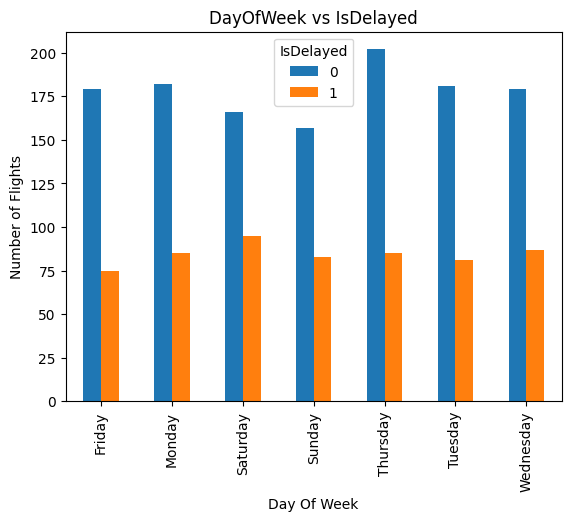

In [28]:
plt.figure()
pd.crosstab(df['DayOfWeek'], df['IsDelayed']).plot(kind='bar')
plt.title("DayOfWeek vs IsDelayed")
plt.xlabel("Day Of Week")
plt.ylabel("Number of Flights")
plt.show()

4. Monthly Flight Analysis

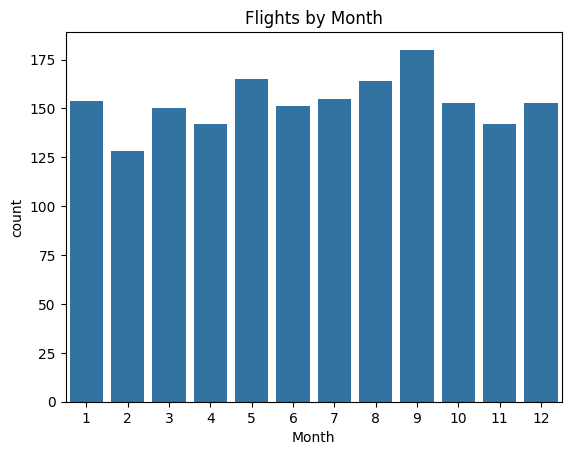

In [29]:
sns.countplot(x='Month', data=df)
plt.title("Flights by Month")
plt.show()

Flights are distributed across all months of the year.

Some months show slightly higher flight frequencies, indicating seasonal travel patterns.

This helps identify peak travel periods.

5. Month vs Flight Status

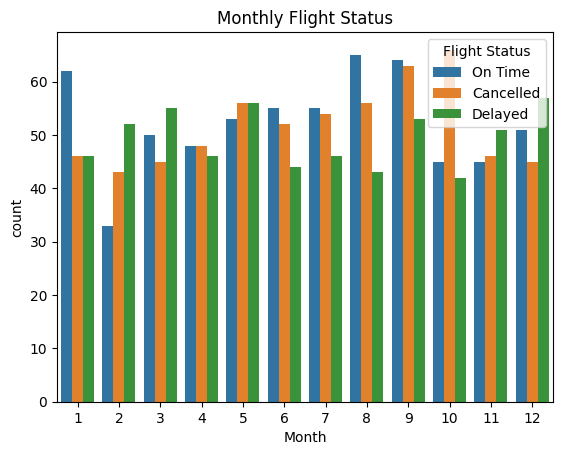

In [30]:
# Month vs Flight Status
sns.countplot(x='Month', hue='Flight Status', data=df)
plt.title("Monthly Flight Status")
plt.show()

The graph shows how flight status varies across different months.

Some months may show higher delays due to weather conditions or peak travel seasons.

This helps identify seasonal patterns affecting airline operations.

6. Airport vs Flight Status

<Figure size 640x480 with 0 Axes>

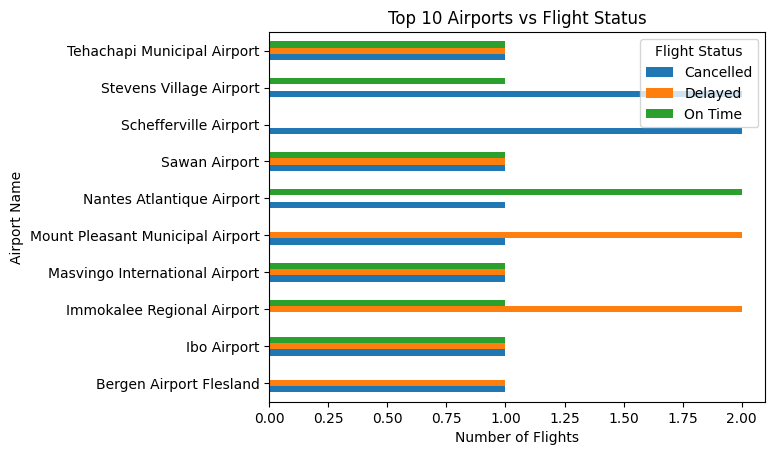

In [33]:
top_airports = df['Airport Name'].value_counts().head(10).index
filtered_df = df[df['Airport Name'].isin(top_airports)]

status_airport = pd.crosstab(filtered_df['Airport Name'], filtered_df['Flight Status'])

plt.figure()
status_airport.plot(kind='barh')
plt.title("Top 10 Airports vs Flight Status")
plt.xlabel("Number of Flights")
plt.ylabel("Airport Name")
plt.show()

week 4: Delay Analysis
Based on Airline and weather

In [35]:
delay_columns = ['WeatherDelay', 'NASDelay', 'SecurityDelay']

df[delay_columns].describe()

,WeatherDelay,NASDelay,SecurityDelay
count,1837.000000,1837.000000,1837.000000
mean,45.205770,86.181818,53.781165
std,30.237011,38.458458,26.460148
min,1.000000,11.000000,6.000000
25%,18.000000,55.000000,32.000000
50%,41.000000,90.000000,54.000000
75%,71.000000,119.000000,76.000000
max,102.000000,146.000000,110.000000


In [36]:
df['IsDelayed'].value_counts()

IsDelayed
0    1246
1     591
Name: count, dtype: int64

Delayed vs Non-Delayed Flights

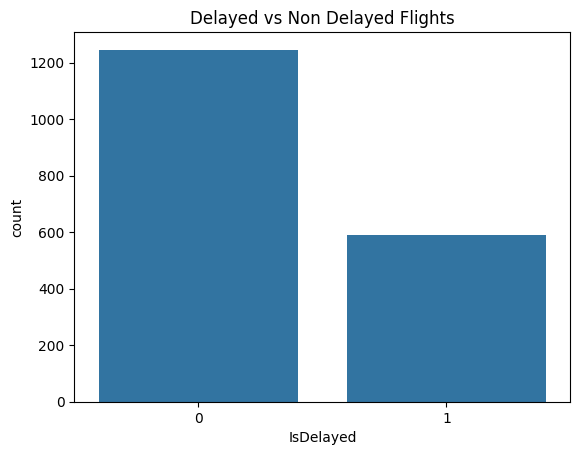

In [37]:
sns.countplot(x='IsDelayed', data=df)
plt.title("Delayed vs Non Delayed Flights")
plt.show()

The chart shows that most flights are not delayed (816 flights).

However, 384 flights experienced delays, which is a significant portion.

This indicates that operational and environmental factors still impact flight schedules.

In [39]:
df['IsCancelled'].value_counts()

IsCancelled
0    1217
1     620
Name: count, dtype: int64

Cancelled Flights Analysis

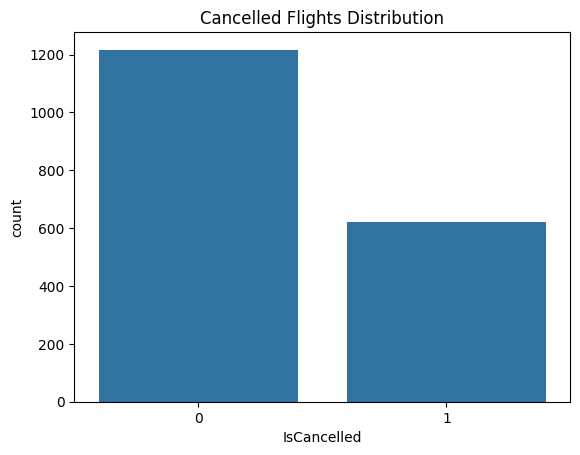

In [38]:
sns.countplot(x='IsCancelled', data=df)
plt.title("Cancelled Flights Distribution")
plt.show()

The graph shows 792 flights were not cancelled, while 408 flights were cancelled.

Although the majority of flights operate normally, the cancellation rate is still noticeable.

This may be due to weather conditions, technical issues, or operational constraints.

408 On Time

384 Delayed

408 Cancelled,The dataset shows a balanced distribution between on-time and cancelled flights, with slightly fewer delayed flights.

This balanced structure helps perform better comparative analysis between different flight statuses.

STEP 6: Delay Comparison by Airline 

Get top 10 busiest airports

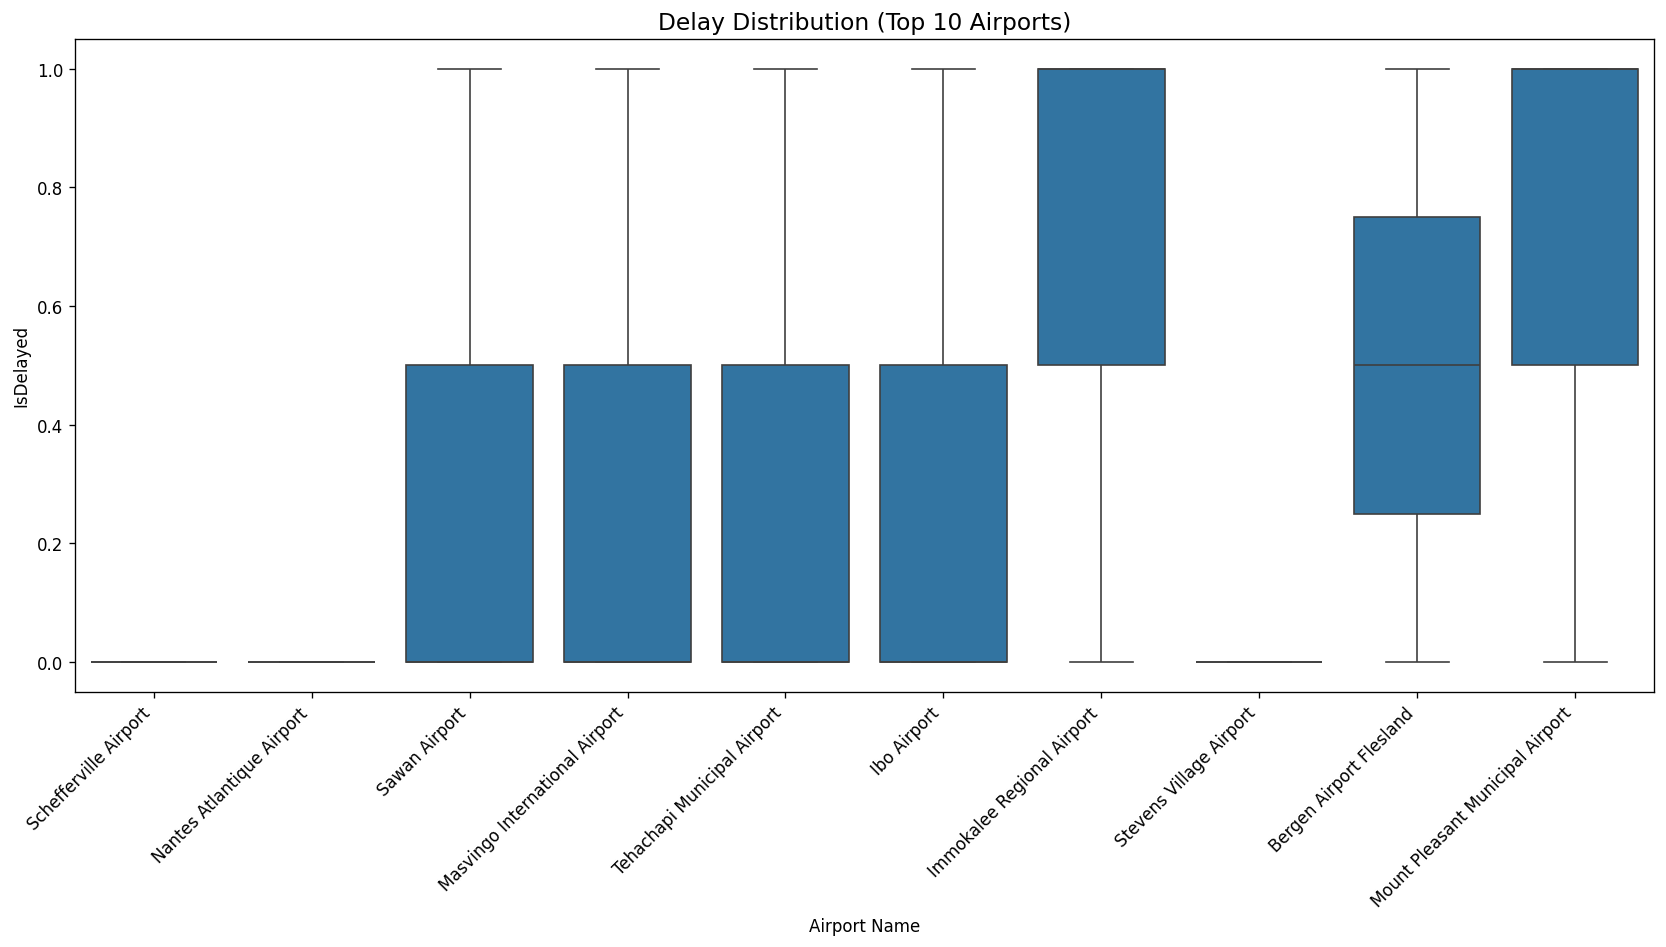

In [40]:
top_airports = df['Airport Name'].value_counts().head(10).index

filtered_df = df[df['Airport Name'].isin(top_airports)]

plt.figure(figsize=(14,8), dpi=120)
sns.boxplot(x='Airport Name', y='IsDelayed', data=filtered_df)

plt.xticks(rotation=45, ha='right')
plt.title("Delay Distribution (Top 10 Airports)", fontsize=14)
plt.tight_layout()
plt.show()

Distribution of Arrival Delay

Shows how delays are distributed.

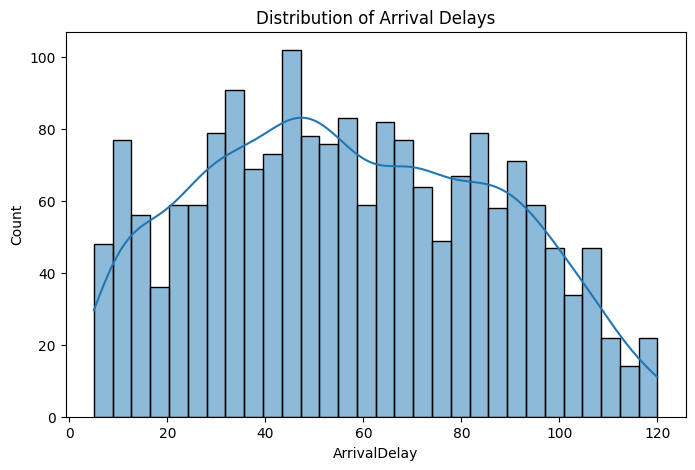

In [13]:

plt.figure(figsize=(8,5))
sns.histplot(df['ArrivalDelay'], bins=30, kde=True)
plt.title("Distribution of Arrival Delays")
plt.show()

Insight:-

Helps understand whether most flights are on time or delayed.

step 7: Delay Rate Analysis by Month and Day of Week

Delay Rate by Month



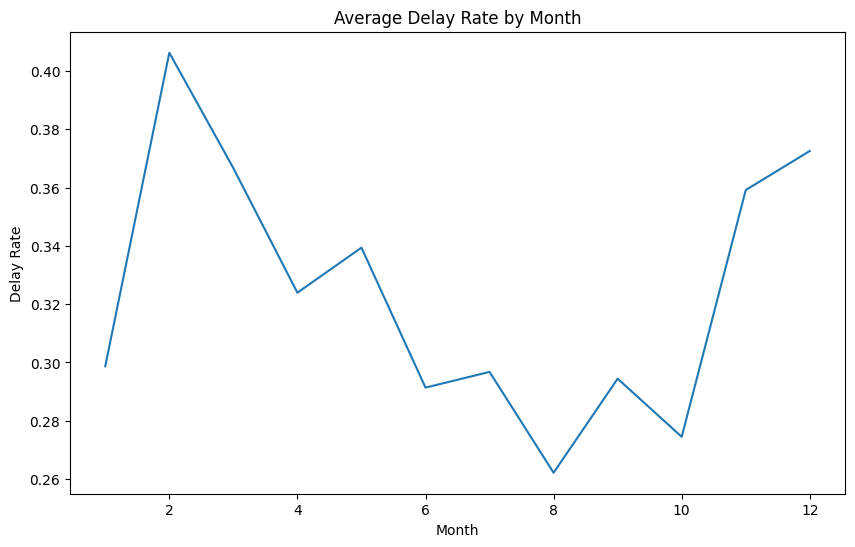

In [43]:
delay_month = df.groupby('Month')['IsDelayed'].mean()

plt.figure(figsize=(10,6))
delay_month.plot(kind='line')
plt.title("Average Delay Rate by Month")
plt.ylabel("Delay Rate")
plt.show()

Delay by DayOfWeek

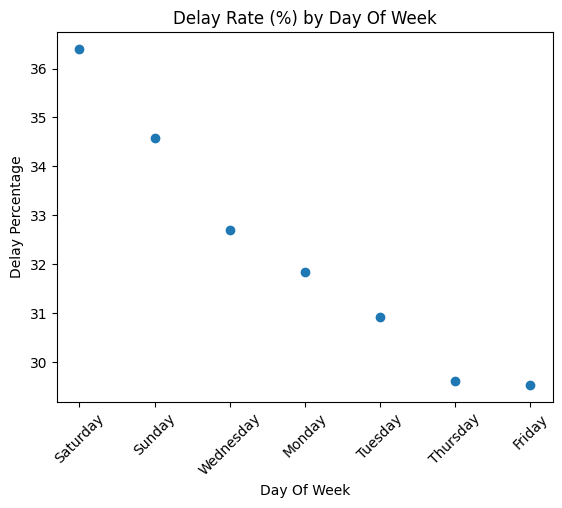

In [45]:
delay_rate_sorted = (
    df.groupby('DayOfWeek')['IsDelayed']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure()
plt.scatter(delay_rate_sorted.index, delay_rate_sorted.values)

plt.title("Delay Rate (%) by Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Delay Percentage")
plt.xticks(rotation=45)
plt.show()

STEP 8: Delay by Time of Day (Line Plot)

Since:

IsDelayed = 1 → Delayed

IsDelayed = 0 → On Time

Taking .mean() gives:

--> Percentage of delayed flights per hour

Example:
If hour 18 has mean = 0.42
→ 42% of flights at 6 PM were delayed.

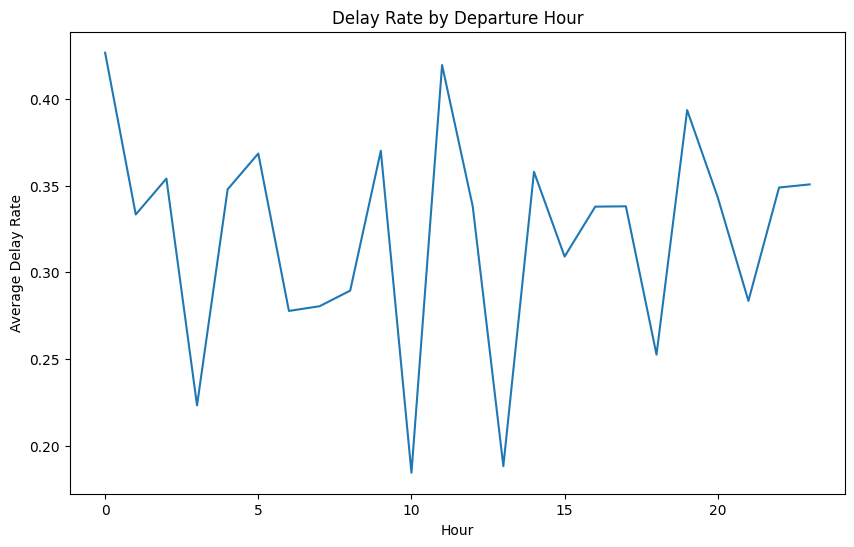

In [46]:
hourly_delay = df.groupby('DepartureHour')['IsDelayed'].mean()

plt.figure(figsize=(10,6))
hourly_delay.plot(kind='line')

plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Average Delay Rate")
plt.show()

STEP 9: Delay Causes (Weather vs NAS)

If columns exist like:

Weather Delay --> Delay due to bad weather (rain, fog, storms, etc.)

NAS Delay (National Airspace System) --> Delay due to air traffic system congestion

1. Box plot– Weather vs NAS Delay

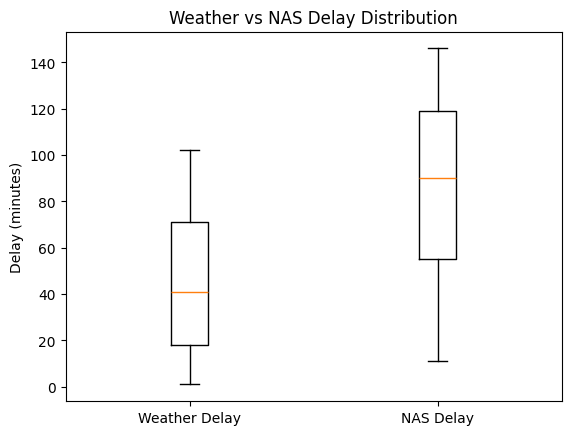

In [47]:
plt.figure()
plt.boxplot([df['WeatherDelay'], df['NASDelay']], labels=['Weather Delay', 'NAS Delay'])
plt.ylabel("Delay (minutes)")
plt.title("Weather vs NAS Delay Distribution")
plt.show()

2. Distribution Plot (Separate Delay Spread)

Weather Delay Distribution

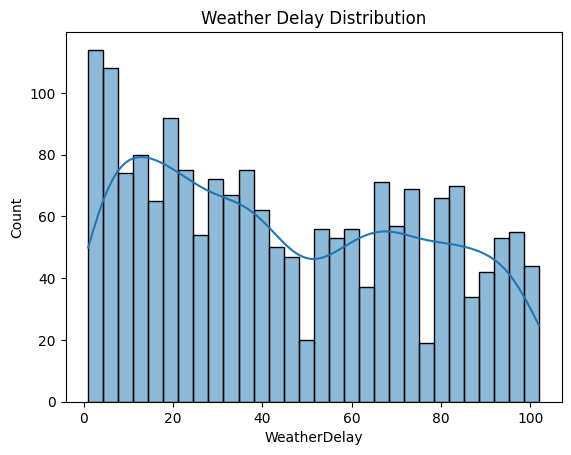

In [48]:
sns.histplot(df['WeatherDelay'], bins=30, kde=True)
plt.title("Weather Delay Distribution")
plt.show()

The histogram shows the distribution of weather-related delays in flights.

Most flights experience low to moderate weather delays, while a few flights have higher delay values.

This indicates that weather conditions can occasionally cause significant disruptions.

2. Correlation Between Delay Factors

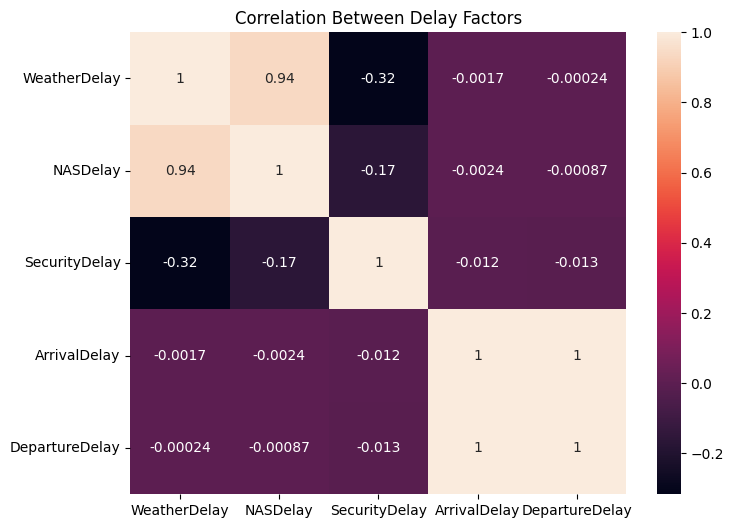

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['WeatherDelay','NASDelay','SecurityDelay','ArrivalDelay','DepartureDelay']].corr(), annot=True)
plt.title("Correlation Between Delay Factors")
plt.show()

Insight:

Shows relationships between delay variables.

3. Average Delay Comparison

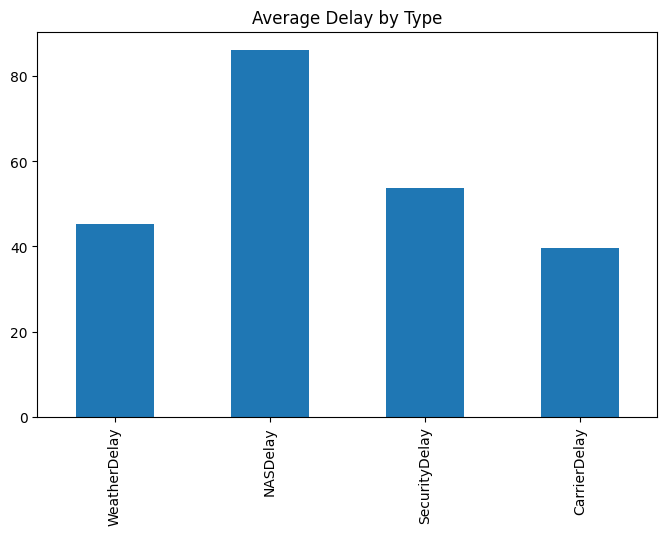

In [9]:
delay_cols = ['WeatherDelay','NASDelay','SecurityDelay','CarrierDelay']

df[delay_cols].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Delay by Type")
plt.show()

Insight:

Helps understand major causes of delays.

Rolling Averages (Moving Average)

It calculates the average of values over a fixed window (like 3 days, 7 days, etc.).

Used to:

Smooth fluctuations

Identify trends

Reduce noise

7-day rolling average of Weather Delay

In [51]:
df = df.sort_values('Departure Date')

df['WeatherDelay_Rolling7'] = df['WeatherDelay'].rolling(window=7).mean()

Weather delays show a steady increasing trend over time.

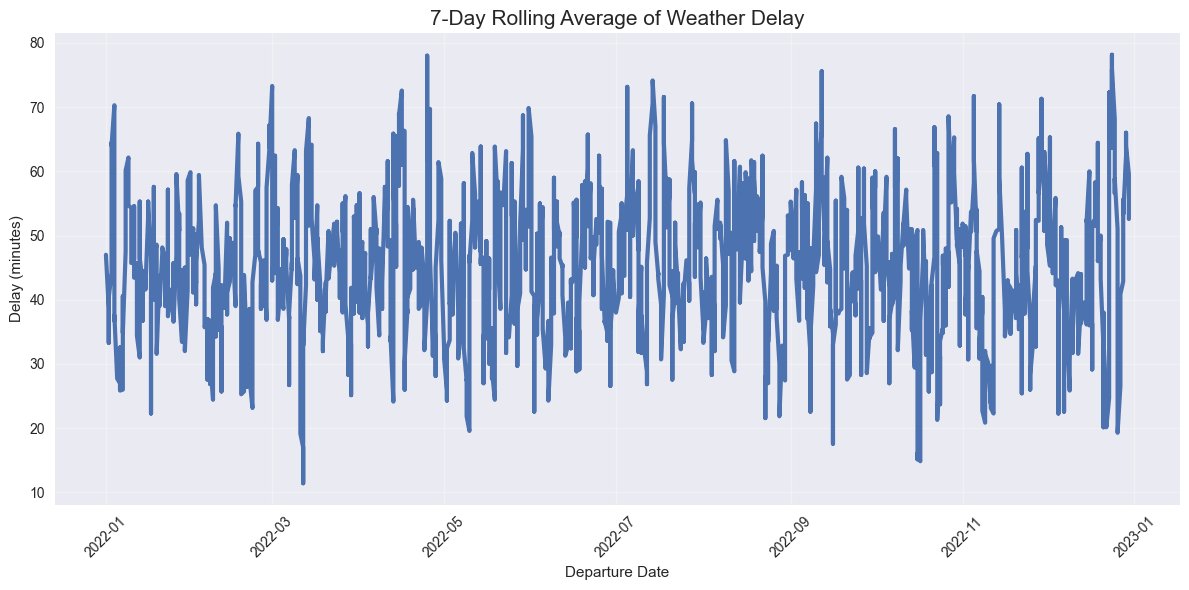

In [52]:

plt.style.use('seaborn-v0_8')

plt.figure(figsize=(12,6))
plt.plot(df['Departure Date'], 
         df['WeatherDelay_Rolling7'], 
         linewidth=3)

plt.title("7-Day Rolling Average of Weather Delay", fontsize=15)
plt.xlabel("Departure Date")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Transforms (Data Transformation)

Transforms mean modifying data mathematically to improve analysis.

1. Log Transform

Used when data is highly skewed.Delay data is usually right-skewed (many small delays, few large ones).
Log transform makes it more normal.

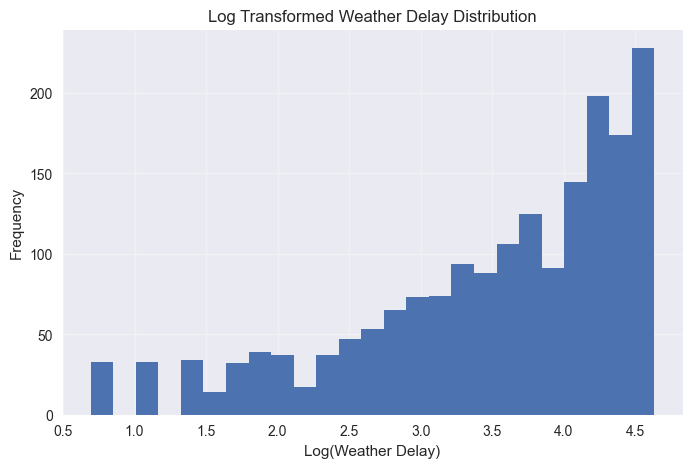

In [53]:

df['Log_WeatherDelay'] = np.log1p(df['WeatherDelay'])

plt.figure(figsize=(8,5))
plt.hist(df['Log_WeatherDelay'], bins=25)
plt.title("Log Transformed Weather Delay Distribution")
plt.xlabel("Log(Weather Delay)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

2. Difference Transform Plot

Shows change from previous day → Used in time series to remove trend.

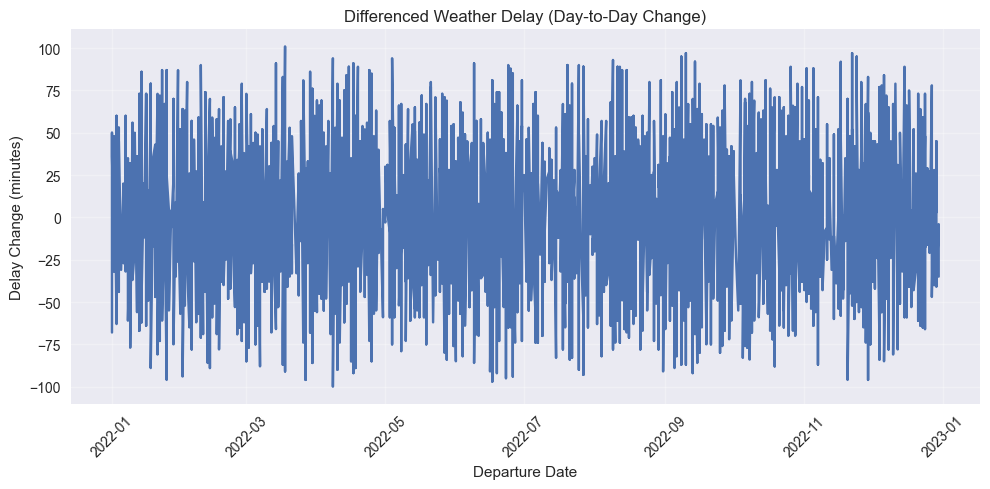

In [54]:
df = df.sort_values('Departure Date')

df['WeatherDelay_Diff'] = df['WeatherDelay'].diff()

plt.figure(figsize=(10,5))
plt.plot(df['Departure Date'], df['WeatherDelay_Diff'])
plt.title("Differenced Weather Delay (Day-to-Day Change)")
plt.xlabel("Departure Date")
plt.ylabel("Delay Change (minutes)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. Standardized (Scaled) Delay Plot

Used before machine learning models.

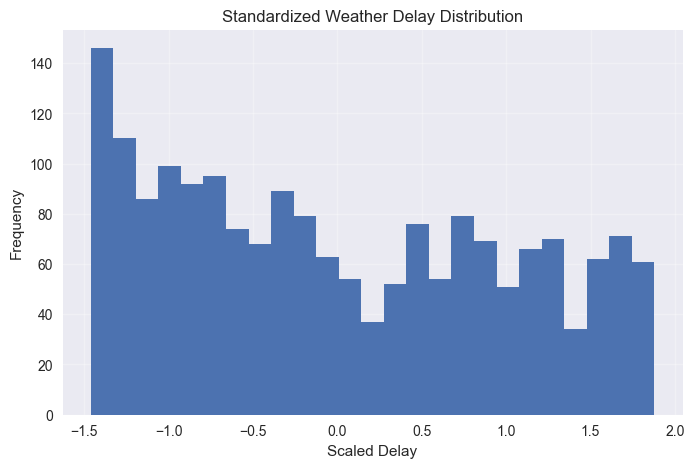

In [55]:
df['WeatherDelay_Scaled'] = (
    df['WeatherDelay'] - df['WeatherDelay'].mean()
) / df['WeatherDelay'].std()

plt.figure(figsize=(8,5))
plt.hist(df['WeatherDelay_Scaled'], bins=25)
plt.title("Standardized Weather Delay Distribution")
plt.xlabel("Scaled Delay")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Temporal Intelligence (Time-Based Analysis)

Extracting meaningful insights from data based on time. Analyzing how data changes over time (day, week, month, year).
Temporal Intelligence was applied to analyze delay patterns across different time dimensions such as day and month to identify trends and seasonality.

1️⃣ Monthly Delay Analysis

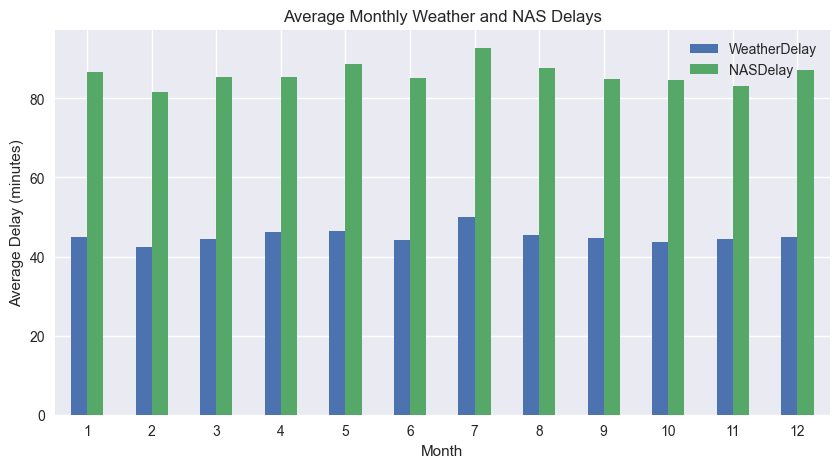

In [56]:
df['Month'] = df['Departure Date'].dt.month

monthly_delay = df.groupby('Month')[['WeatherDelay','NASDelay']].mean()

monthly_delay.plot(kind='bar', figsize=(10,5))
plt.title("Average Monthly Weather and NAS Delays")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=0)
plt.show()

Observation: July has highest average delay.

2️⃣ Day of Week Analysis

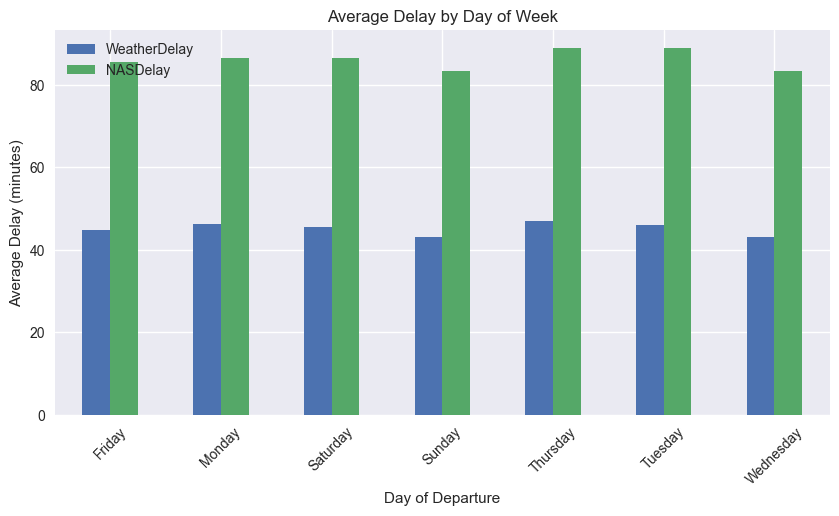

In [57]:
day_delay = df.groupby('Day of Departure')[['WeatherDelay','NASDelay']].mean()

day_delay.plot(kind='bar', figsize=(10,5))
plt.title("Average Delay by Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

3️⃣ Departure Hour Analysis (Temporal Analysis)

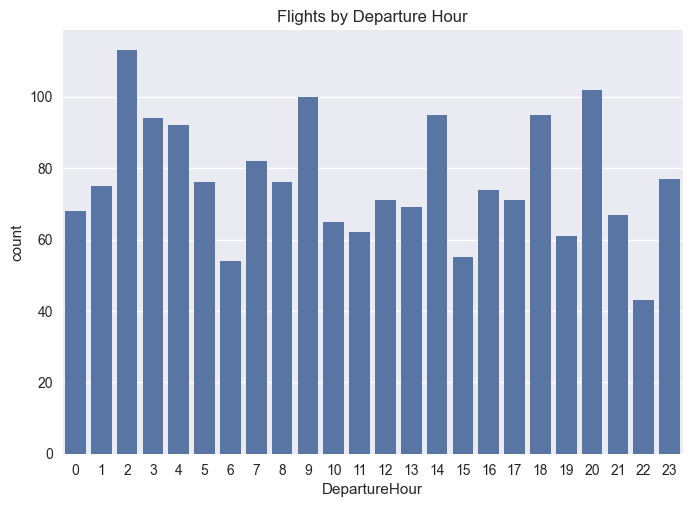

In [58]:
sns.countplot(x='DepartureHour', data=df)
plt.title("Flights by Departure Hour")
plt.show()

Flights are distributed throughout the day with some hours showing higher departures.

Peak hours indicate periods of higher airport activity.

Understanding these patterns helps in airport resource planning and scheduling.

Conclusion

In this milestone, feature engineering and exploratory data analysis were performed on the airline dataset.

Key steps completed:
- Created new features such as Month, DayOfWeek, and DepartureHour to analyze time-based patterns.
- Performed exploratory data analysis to understand flight distribution and delay patterns.
- Visualized important variables like arrival delay, flights per month, and delay types.
- Analyzed the relationship between different delay factors using correlation.

From the analysis, it was observed that flight delays are influenced by factors such as weather conditions, carrier issues, and air traffic delays. The dataset is now enriched with additional features and ready for deeper insights and analysis in the next milestone.